# Jupyter Notebook for constraining the detectable DM subhalo parameter space with TESS
## Used to generate Fig. 3 of the letter

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
plt.rcParams['text.usetex'] = True
plt.rc('font', family = 'roman')

In [2]:
# Physical constants and unit conversions

M_sun = 1.989*1e30                   # Solar mass in kg
AU = 149.6*1e9                       # Astronomical unit in m
G = 6.67*1e-11                       # Gravitational constant in m^3 / (kg s^2)
c = 2.99792458*1e8                   # Speed of light in m/s

pc_to_AU = 206265                    # Parsec to astronomical unit conversion
rad_to_arcsec = (3600*180)/np.pi     # Radian to arcsecond conversion
year_to_sec = 365*24*3600            # Year to second conversion

In [3]:
# Acceleration sensitivities of different astrometric probes
sigma_TESS_poles = 6.3*1e-9                          # TESS sensitivity for NEP CVZ (best value obtained)
sigma_Gaia = 2.3*1e-10                               # Gaia SSB acceleration sensitivity estimate (https://arxiv.org/abs/2012.02036)
sigma_PTA = np.array([2*1e-19, 2*1e-18])*c           # Pulsar timing SSB acceleration sensitivity range (https://arxiv.org/abs/astro-ph/0506548)

In [4]:
# Detectable subhalo mass in solar masses as a function of subhalo distance in AU depending on acceleration sensitivity
def M_of_d(d_DM, sigma):
    return sigma/G*d_DM**2*AU**2/M_sun

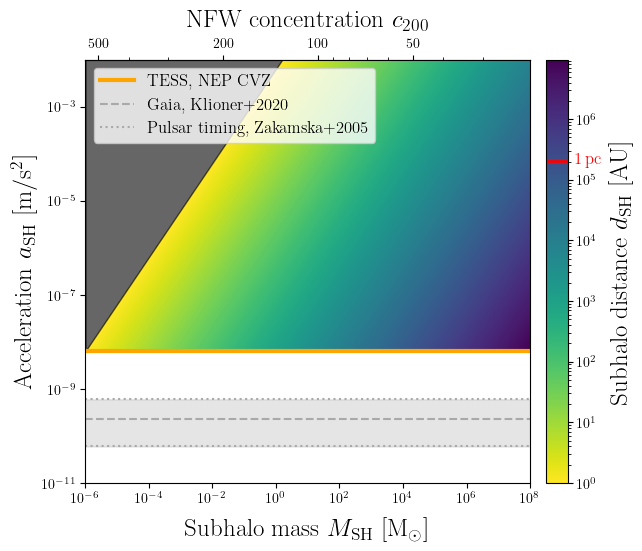

In [6]:
# Plotting the accessible parameter range

# Grid of subhalo distances (AU) and masses (solar masses)
d_DM_val_grid_2 = np.logspace(0,8,1000)                                # in AU
M_DM_val_grid_2 = np.logspace(-6,8,1000)                               # in M_sun
D_grid_2, M_grid_2 = np.meshgrid(d_DM_val_grid_2, M_DM_val_grid_2)

d_min = np.min(d_DM_val_grid_2)

# Gravitational acceleration induced by a subhalo (assumed to be constant)
A_grid = G * M_grid_2 * M_sun / (D_grid_2 * AU)**2

# Detectable region according to TESS acceleration sensitivity for NEP CVZ
mask_2 = A_grid >= sigma_TESS_poles
D_plot = np.ma.masked_where(~mask_2, D_grid_2)

fig, ax = plt.subplots(figsize=(7,5.5))

# ==========================================================
# Sensitivity curves of different probes
# ==========================================================

# TESS acceleration sensitivity curve
M_lim_TESS = M_of_d(d_DM_val_grid_2, sigma_TESS_poles)
A_lim_TESS = G * M_lim_TESS * M_sun / (d_DM_val_grid_2 * AU)**2
ax.loglog(M_lim_TESS, A_lim_TESS, color="orange", label="TESS, NEP CVZ", lw=3)

# Gaia acceleration sensitivity
A_lim_Gaia = sigma_Gaia*np.ones(len(M_DM_val_grid_2))
ax.loglog(M_DM_val_grid_2, A_lim_Gaia, color="darkgray", ls="--", label="Gaia, Klioner+2020")

# Pulsar timing acceleration sensitivity range
A1_PTA = sigma_PTA[0]*np.ones(len(M_DM_val_grid_2))
A2_PTA = sigma_PTA[1]*np.ones(len(M_DM_val_grid_2))
ax.loglog(M_DM_val_grid_2, A1_PTA, color="darkgray", ls=":", label="Pulsar timing, Zakamska+2005")
ax.loglog(M_DM_val_grid_2, A2_PTA, color="darkgray", ls=":")
ax.fill_between(M_DM_val_grid_2, A1_PTA, A2_PTA, color="darkgray", alpha=0.3)

# ==========================================================
# Detectable subhalo parameter space
# ==========================================================

# Color-coded distance of detectable subhalos
pcm = ax.pcolormesh(
    M_grid_2,
    A_grid,
    D_plot,
    shading="auto",
    cmap="viridis_r",
    norm=colors.LogNorm(vmin=np.min(D_plot), vmax=np.max(D_plot))
)

# ==========================================================
# Lower distance boundary (black region)
# ==========================================================

# Region corresponding to distances below the considered minimum distance
a_max = G * M_DM_val_grid_2 * M_sun / (d_min*AU)**2
mask_amax = a_max > sigma_TESS_poles

ax.fill_between(
    M_DM_val_grid_2[mask_amax],
    a_max[mask_amax],
    1e-1,
    facecolor=(0,0,0,0.6),
    edgecolor=(0,0,0,0.6)
)

# ==========================================================
# Axes
# ==========================================================

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(1e-6,1e8)
ax.set_ylim(1e-11,1e-2)

ax.set_xlabel(r"Subhalo mass $M_\mathrm{SH}$ [$\mathrm{M_\odot}$]", fontsize=18, labelpad=8)
ax.set_ylabel(r"Acceleration $a_\mathrm{SH}$ [$\mathrm{m/s^2}$]", fontsize=18)

# ==========================================================
# Secondary x-axis: NFW concentration c_200
# ==========================================================

# Conversion between subhalo mass and concentration using
# the Dutton & Macciò (2014) concentration-mass relation (https://doi.org/10.1093/mnras/stu742) 
# and Planck 2018's Hubble-parameter (https://doi.org/10.1051/0004-6361/201833910)
def c200_of_M(M):
    return 10**0.905*(M*0.674/1e12)**(-0.101)

def M_of_c200(c):
    c = np.asarray(c)
    M = np.full_like(c, np.nan, dtype=float)

    mask_c = c > 0
    M[mask_c] = (1e12/0.674)*(c[mask_c]/10**0.905)**(-1/0.101)

    return M

secax = ax.secondary_xaxis("top", functions=(c200_of_M, M_of_c200))
secax.set_xlabel(r"NFW concentration $c_{200}$", fontsize=18, labelpad=8)

c_ticks = np.array([20, 50, 100, 200, 500, 600])

secax.set_xticks(c_ticks)
secax.set_xticklabels([f"{c:.0f}" for c in c_ticks])

# ==========================================================
# Colorbar: subhalo distance
# ==========================================================

cbar = fig.colorbar(pcm, ax=ax, pad=0.03)
cbar.set_label(r"Subhalo distance $d_\mathrm{SH}$ [AU]", fontsize=18, labelpad=8)

# Mark 1 pc reference distance on the colorbar
cbar.ax.plot(
    [0, 1],
    [pc_to_AU, pc_to_AU],
    color="red",
    linestyle="solid",
    linewidth=2,
    transform=cbar.ax.get_yaxis_transform()
)

cbar.ax.text(
    2,
    0.8*pc_to_AU,
    r"$1\,\mathrm{pc}$",
    color="red",
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="bottom",
    transform=cbar.ax.get_yaxis_transform()
)

ax.legend(loc="upper left", fontsize=12)
plt.show()